In [4]:
import xgboost as xgb
import model_XGBoost as xgb_model

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.relativedelta import relativedelta
import datetime as dt
import holidays
holidays_de= holidays.Germany()

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import scipy.stats as stats

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [5]:
df_all = pd.read_csv('../../data_cleaned/merged/02_4_clean_data.csv')
df_all = df_all[df_all["hour"] == 15].copy()
df_all.head()

,date,year,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
15,2019-01-01,2019,1,1,1,15,1,1.97,2019-01-01 15:00:00+00:00,2019-01-01 16:00:00+00:00,...,38732.2975,0.000000,1.000000,-0.707107,-0.707107,0.781831,0.623490,1,holiday,22.280
39,2019-01-02,2019,1,2,2,15,2,56.01,2019-01-02 15:00:00+00:00,2019-01-02 16:00:00+00:00,...,23604.9475,0.017202,0.999852,-0.707107,-0.707107,0.974928,-0.222521,0,weekday,22.280
63,2019-01-03,2019,1,3,3,15,3,68.41,2019-01-03 15:00:00+00:00,2019-01-03 16:00:00+00:00,...,10880.3425,0.034398,0.999408,-0.707107,-0.707107,0.433884,-0.900969,0,weekday,22.215
87,2019-01-04,2019,1,4,4,15,4,52.59,2019-01-04 15:00:00+00:00,2019-01-04 16:00:00+00:00,...,26184.0075,0.051584,0.998669,-0.707107,-0.707107,-0.433884,-0.900969,0,weekday,22.845
111,2019-01-05,2019,1,5,5,15,5,56.62,2019-01-05 15:00:00+00:00,2019-01-05 16:00:00+00:00,...,19620.5225,0.068755,0.997634,-0.707107,-0.707107,-0.974928,-0.222521,0,weekend,22.930


In [6]:
df_years = df_all.query('2019 <= year').copy()
df_years.head()

,date,year,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
15,2019-01-01,2019,1,1,1,15,1,1.97,2019-01-01 15:00:00+00:00,2019-01-01 16:00:00+00:00,...,38732.2975,0.000000,1.000000,-0.707107,-0.707107,0.781831,0.623490,1,holiday,22.280
39,2019-01-02,2019,1,2,2,15,2,56.01,2019-01-02 15:00:00+00:00,2019-01-02 16:00:00+00:00,...,23604.9475,0.017202,0.999852,-0.707107,-0.707107,0.974928,-0.222521,0,weekday,22.280
63,2019-01-03,2019,1,3,3,15,3,68.41,2019-01-03 15:00:00+00:00,2019-01-03 16:00:00+00:00,...,10880.3425,0.034398,0.999408,-0.707107,-0.707107,0.433884,-0.900969,0,weekday,22.215
87,2019-01-04,2019,1,4,4,15,4,52.59,2019-01-04 15:00:00+00:00,2019-01-04 16:00:00+00:00,...,26184.0075,0.051584,0.998669,-0.707107,-0.707107,-0.433884,-0.900969,0,weekday,22.845
111,2019-01-05,2019,1,5,5,15,5,56.62,2019-01-05 15:00:00+00:00,2019-01-05 16:00:00+00:00,...,19620.5225,0.068755,0.997634,-0.707107,-0.707107,-0.974928,-0.222521,0,weekend,22.930


In [7]:
df_years = pd.get_dummies(df_years, columns=['year'], drop_first=True)
df_years.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,load_forecast_da,...,dayofweek_cos1,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
15,2019-01-01,1,1,1,15,1,1.97,2019-01-01 15:00:00+00:00,2019-01-01 16:00:00+00:00,51301.3825,...,0.623490,1,holiday,22.280,False,False,False,False,False,False
39,2019-01-02,1,2,2,15,2,56.01,2019-01-02 15:00:00+00:00,2019-01-02 16:00:00+00:00,62306.0625,...,-0.222521,0,weekday,22.280,False,False,False,False,False,False
63,2019-01-03,1,3,3,15,3,68.41,2019-01-03 15:00:00+00:00,2019-01-03 16:00:00+00:00,63761.8450,...,-0.900969,0,weekday,22.215,False,False,False,False,False,False
87,2019-01-04,1,4,4,15,4,52.59,2019-01-04 15:00:00+00:00,2019-01-04 16:00:00+00:00,60812.3575,...,-0.900969,0,weekday,22.845,False,False,False,False,False,False
111,2019-01-05,1,5,5,15,5,56.62,2019-01-05 15:00:00+00:00,2019-01-05 16:00:00+00:00,57096.1850,...,-0.222521,0,weekend,22.930,False,False,False,False,False,False


In [8]:
df_years.drop(columns=['period_end_utc'], inplace=True)

In [9]:
df_years["period_start_utc"] = pd.to_datetime(df_years["period_start_utc"], errors="coerce")
df_years["period_start_utc"] = df_years["period_start_utc"].apply(lambda x: x.replace(tzinfo=None))
df_years["date"] = pd.to_datetime(df_years["date"], errors="coerce")

In [10]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2557 entries, 15 to 61359
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2557 non-null   datetime64[ns]
 1   month             2557 non-null   int64         
 2   day               2557 non-null   int64         
 3   dayofyear         2557 non-null   int64         
 4   hour              2557 non-null   int64         
 5   dayofweek         2557 non-null   int64         
 6   price             2557 non-null   float64       
 7   period_start_utc  2557 non-null   datetime64[ns]
 8   load_forecast_da  2557 non-null   float64       
 9   off_wind_da       2557 non-null   float64       
 10  on_wind_da        2557 non-null   float64       
 11  solar_da          2557 non-null   float64       
 12  gen_forecast_da   2557 non-null   float64       
 13  res_sum_da        2557 non-null   float64       
 14  dayofyear_sin1    2557 non-

In [11]:
df_years.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_start_utc,load_forecast_da,off_wind_da,...,dayofweek_cos1,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
15,2019-01-01,1,1,1,15,1,1.97,2019-01-01 15:00:00,51301.3825,4334.6125,...,0.623490,1,holiday,22.280,False,False,False,False,False,False
39,2019-01-02,1,2,2,15,2,56.01,2019-01-02 15:00:00,62306.0625,3448.0850,...,-0.222521,0,weekday,22.280,False,False,False,False,False,False
63,2019-01-03,1,3,3,15,3,68.41,2019-01-03 15:00:00,63761.8450,1975.5200,...,-0.900969,0,weekday,22.215,False,False,False,False,False,False
87,2019-01-04,1,4,4,15,4,52.59,2019-01-04 15:00:00,60812.3575,4499.3450,...,-0.900969,0,weekday,22.845,False,False,False,False,False,False
111,2019-01-05,1,5,5,15,5,56.62,2019-01-05 15:00:00,57096.1850,3264.1850,...,-0.222521,0,weekend,22.930,False,False,False,False,False,False


In [12]:
df_years.set_index('period_start_utc', inplace=True)

In [13]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-01-01 15:00:00 to 2025-12-31 15:00:00
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2557 non-null   datetime64[ns]
 1   month             2557 non-null   int64         
 2   day               2557 non-null   int64         
 3   dayofyear         2557 non-null   int64         
 4   hour              2557 non-null   int64         
 5   dayofweek         2557 non-null   int64         
 6   price             2557 non-null   float64       
 7   load_forecast_da  2557 non-null   float64       
 8   off_wind_da       2557 non-null   float64       
 9   on_wind_da        2557 non-null   float64       
 10  solar_da          2557 non-null   float64       
 11  gen_forecast_da   2557 non-null   float64       
 12  res_sum_da        2557 non-null   float64       
 13  dayofyear_sin1    2557 non-null   float64 

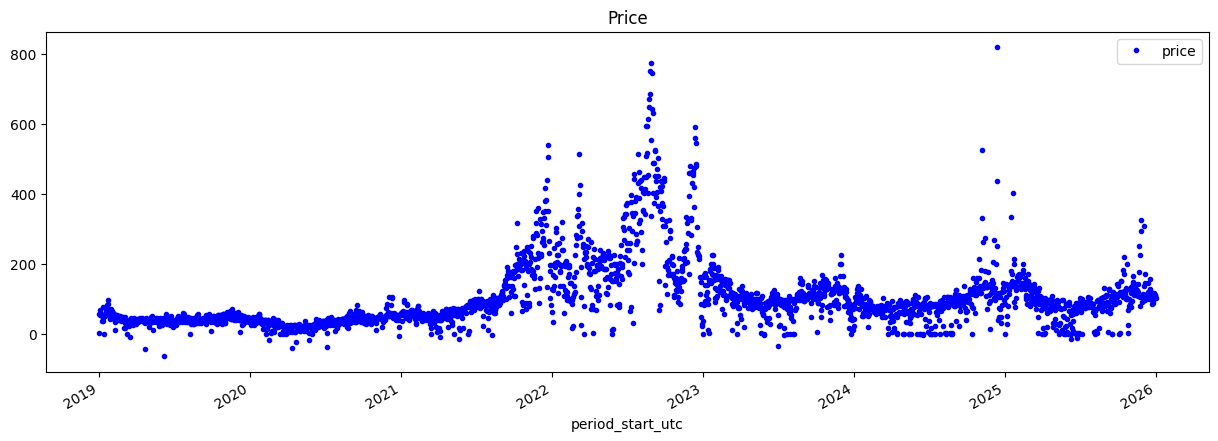

In [14]:
df_years.plot( y='price', style='.', figsize=(15, 5), color='blue', title='Price')
plt.show()

# Train / Test Split

In [15]:
start_date = pd.to_datetime('2019-01-01 00:00:00')
split_date = pd.to_datetime('2025-01-01 00:00:00')
end_date = pd.to_datetime('2026-01-01 00:00:00')

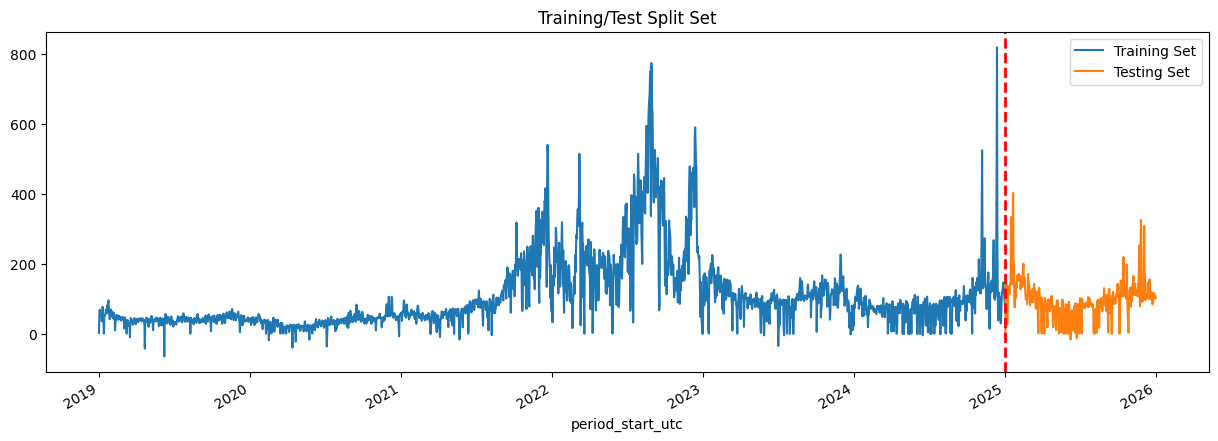

In [16]:
train = df_years.query('@start_date <= date < @split_date')
test = df_years.query('@split_date <= date < @end_date')

#train = df_years.query('date < 2021')
#test = df_years.query('2021 <= date < "2021-07"')

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(y='price', ax=ax, label='Training Set', title='Training/Test Split Set')
test.plot(y='price', ax=ax, label = 'Testing Set')
ax.axvline(split_date, color='red', linestyle='dashed', linewidth=2)
plt.legend()
plt.show()

# Feature Creation

In [17]:
df_years.index

DatetimeIndex(['2019-01-01 15:00:00', '2019-01-02 15:00:00',
               '2019-01-03 15:00:00', '2019-01-04 15:00:00',
               '2019-01-05 15:00:00', '2019-01-06 15:00:00',
               '2019-01-07 15:00:00', '2019-01-08 15:00:00',
               '2019-01-09 15:00:00', '2019-01-10 15:00:00',
               ...
               '2025-12-22 15:00:00', '2025-12-23 15:00:00',
               '2025-12-24 15:00:00', '2025-12-25 15:00:00',
               '2025-12-26 15:00:00', '2025-12-27 15:00:00',
               '2025-12-28 15:00:00', '2025-12-29 15:00:00',
               '2025-12-30 15:00:00', '2025-12-31 15:00:00'],
              dtype='datetime64[ns]', name='period_start_utc', length=2557, freq=None)

In [18]:
# def create_features(df):
#     """
#     create time series features based on time series index
#     :param df:
#     :return:
#     """
#     df = df.copy()

#     df['hour'] = df.index.hour
#     df['dayofweek'] = df.index.dayofweek
#     df['weekday'] = df.index.weekday
#     df['quarter'] = df.index.quarter
#     df['month'] = df.index.month
#     df['year'] = df.index.year
#     df['dayofyear'] = df.index.dayofyear
#     return df

Text(0.5, 1.0, 'Price by Hour')

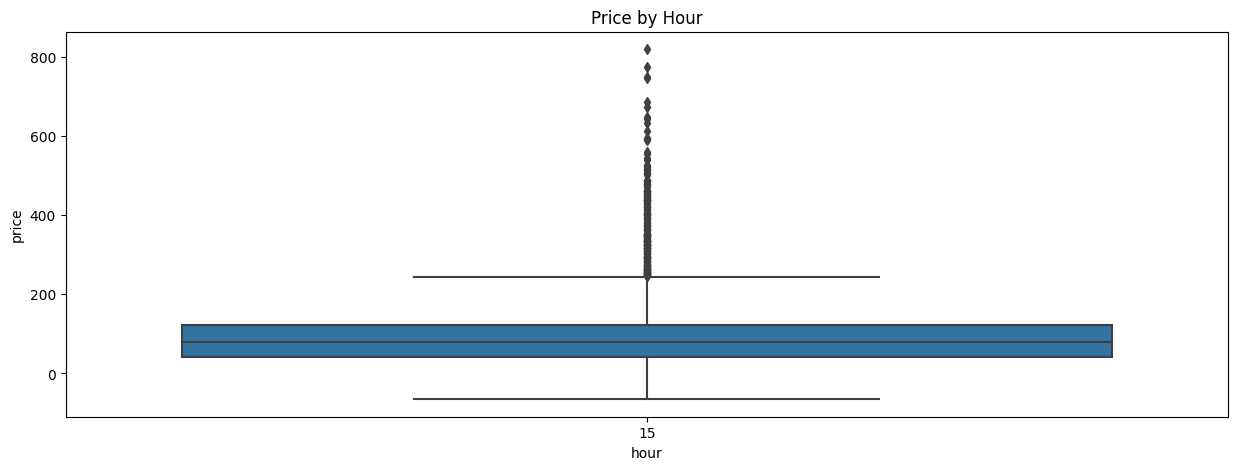

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'hour', y= 'price')
ax.set_title('Price by Hour')

Text(0.5, 1.0, 'Price by Month')

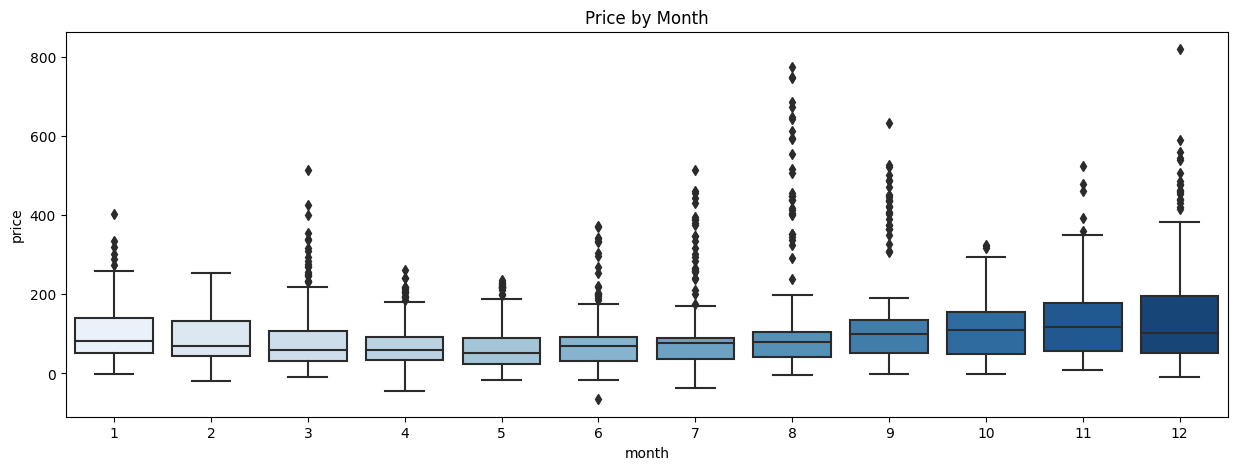

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'month', y= 'price', palette='Blues')
ax.set_title('Price by Month')

# Create Model

In [21]:
df_years.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'load_forecast_da', 'off_wind_da', 'on_wind_da', 'solar_da',
       'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1', 'dayofyear_cos1',
       'hour_sin1', 'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1',
       'is_holiday', 'day_type', 'price_gas', 'year_2020', 'year_2021',
       'year_2022', 'year_2023', 'year_2024', 'year_2025'],
      dtype='object')

In [22]:
#FEATURES = ['year', 'month', 'day', 'dayofyear', 'hour', 'week', 'dayofweek', 'load_forecast_da', 'res_sum_da', 'dayofyear_sin1',
#       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
#       'dayofweek_cos1', 'is_holiday', 'price_gas']
FEATURES = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'price_gas', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025']
#FEATURES = ['year', 'price_gas', 'res_sum_da', 'load_forecast_da']
TARGET = 'price'

In [23]:
reg = xgb_model.create_and_train_XGBoost(train, test, FEATURES, TARGET)

[0]	validation_0-rmse:145.70780	validation_1-rmse:108.78565
[50]	validation_0-rmse:95.19214	validation_1-rmse:75.98992
[100]	validation_0-rmse:63.03689	validation_1-rmse:57.27673


c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [16:13:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[150]	validation_0-rmse:43.81635	validation_1-rmse:46.35199
[200]	validation_0-rmse:31.78997	validation_1-rmse:40.42785
[250]	validation_0-rmse:24.48647	validation_1-rmse:37.25933
[300]	validation_0-rmse:20.09519	validation_1-rmse:35.27851
[350]	validation_0-rmse:17.30966	validation_1-rmse:33.93166
[400]	validation_0-rmse:15.58372	validation_1-rmse:33.08539
[450]	validation_0-rmse:14.36374	validation_1-rmse:32.55374
[500]	validation_0-rmse:13.52116	validation_1-rmse:32.21896
[550]	validation_0-rmse:12.86145	validation_1-rmse:31.96979
[600]	validation_0-rmse:12.32508	validation_1-rmse:31.91562
[650]	validation_0-rmse:11.84559	validation_1-rmse:31.86077
[700]	validation_0-rmse:11.42512	validation_1-rmse:31.85564
[750]	validation_0-rmse:11.06193	validation_1-rmse:31.83201
[800]	validation_0-rmse:10.72423	validation_1-rmse:31.84090
[850]	validation_0-rmse:10.42553	validation_1-rmse:31.83919
[900]	validation_0-rmse:10.14667	validation_1-rmse:31.86788
[950]	validation_0-rmse:9.85918	validati

In [24]:
#reg.score()

# Feature Importance

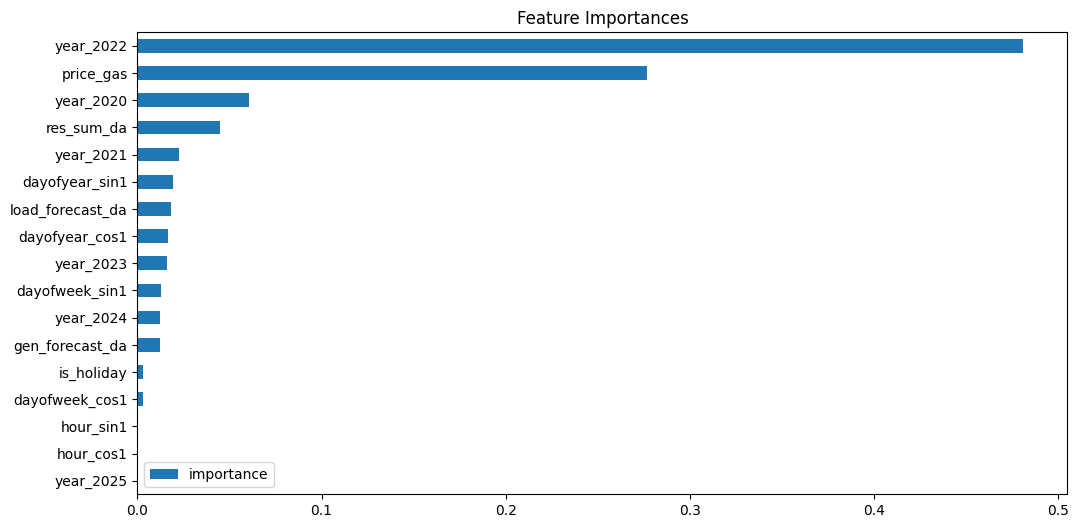

In [25]:
xgb_model.display_feature_importance(reg)

# Forecast on Test

In [26]:
test['prediction'] = reg.predict(test[FEATURES])

C:\Users\sonja\AppData\Local\Temp\ipykernel_22644\677415749.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(test[FEATURES])


In [27]:
df_years = df_years.merge(test[['prediction']],  how = 'left', left_index=True, right_index=True) # merge on index columns

In [28]:
df_years

,date,month,day,dayofyear,hour,dayofweek,price,load_forecast_da,off_wind_da,on_wind_da,...,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025,prediction
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 15:00:00,2019-01-01,1,1,1,15,1,1.9700,51301.3825,4334.6125,34378.2275,...,1,holiday,22.2800,False,False,False,False,False,False,NaN
2019-01-02 15:00:00,2019-01-02,1,2,2,15,2,56.0100,62306.0625,3448.0850,20094.0975,...,0,weekday,22.2800,False,False,False,False,False,False,NaN
2019-01-03 15:00:00,2019-01-03,1,3,3,15,3,68.4100,63761.8450,1975.5200,8861.9575,...,0,weekday,22.2150,False,False,False,False,False,False,NaN
2019-01-04 15:00:00,2019-01-04,1,4,4,15,4,52.5900,60812.3575,4499.3450,21657.7500,...,0,weekday,22.8450,False,False,False,False,False,False,NaN
2019-01-05 15:00:00,2019-01-05,1,5,5,15,5,56.6200,57096.1850,3264.1850,16343.8950,...,0,weekend,22.9300,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 15:00:00,2025-12-27,12,27,361,15,5,103.0075,53710.4525,6087.8775,17523.3875,...,0,weekend,28.0950,False,False,False,False,False,True,70.001823
2025-12-28 15:00:00,2025-12-28,12,28,362,15,6,110.8825,54811.3450,2348.1600,10527.3975,...,0,weekend,28.2725,False,False,False,False,False,True,80.945549
2025-12-29 15:00:00,2025-12-29,12,29,363,15,0,108.6550,65691.9450,6022.8500,20705.2875,...,0,weekday,28.4500,False,False,False,False,False,True,78.271912


In [29]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-01-01 15:00:00 to 2025-12-31 15:00:00
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2557 non-null   datetime64[ns]
 1   month             2557 non-null   int64         
 2   day               2557 non-null   int64         
 3   dayofyear         2557 non-null   int64         
 4   hour              2557 non-null   int64         
 5   dayofweek         2557 non-null   int64         
 6   price             2557 non-null   float64       
 7   load_forecast_da  2557 non-null   float64       
 8   off_wind_da       2557 non-null   float64       
 9   on_wind_da        2557 non-null   float64       
 10  solar_da          2557 non-null   float64       
 11  gen_forecast_da   2557 non-null   float64       
 12  res_sum_da        2557 non-null   float64       
 13  dayofyear_sin1    2557 non-null   float64 

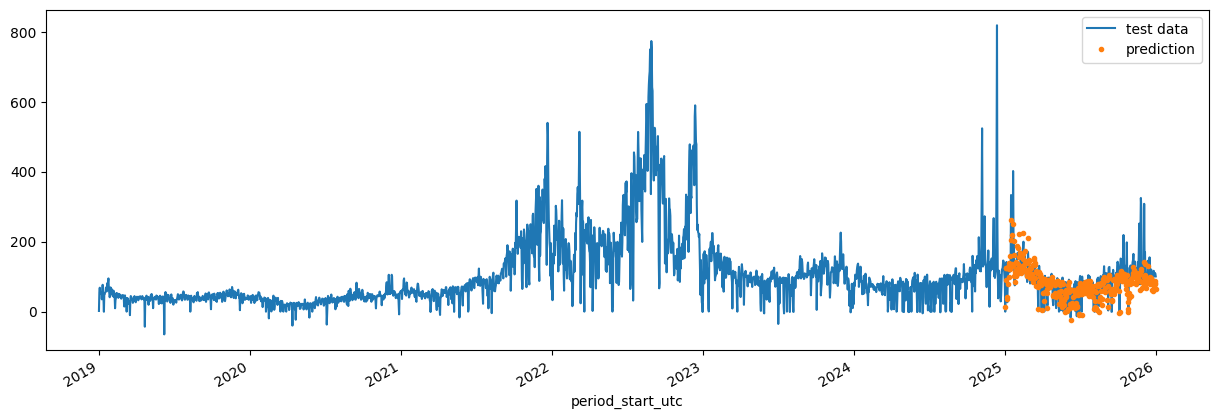

Text(0.5, 1.0, 'Test Data and Predictions')

In [30]:
ax = df_years[['price']].plot(figsize=(15, 5))
df_years['prediction'].plot(ax=ax, style = '.')
plt.legend(['test data', 'prediction'])
plt.show()
ax.set_title('Test Data and Predictions')

# smaller test frames

In [31]:
add_three_months = relativedelta(months=3)
add_one_week = relativedelta(days=7)

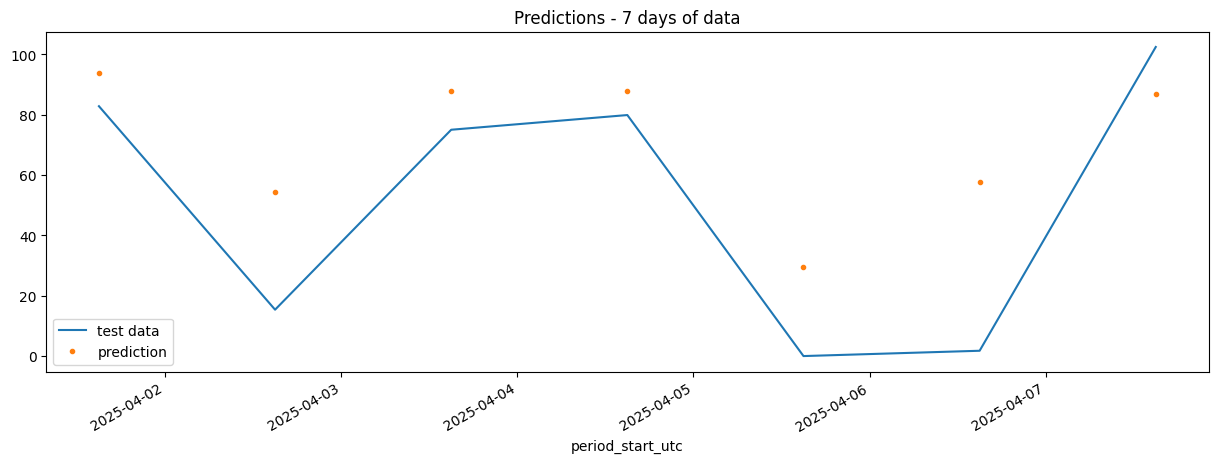

In [32]:
first_day_four_months_in = split_date + add_three_months
first_day_four_months_in.to_datetime64()
last_day_four_months_in = first_day_four_months_in + add_one_week
last_day_four_months_in.to_datetime64()

ax = df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

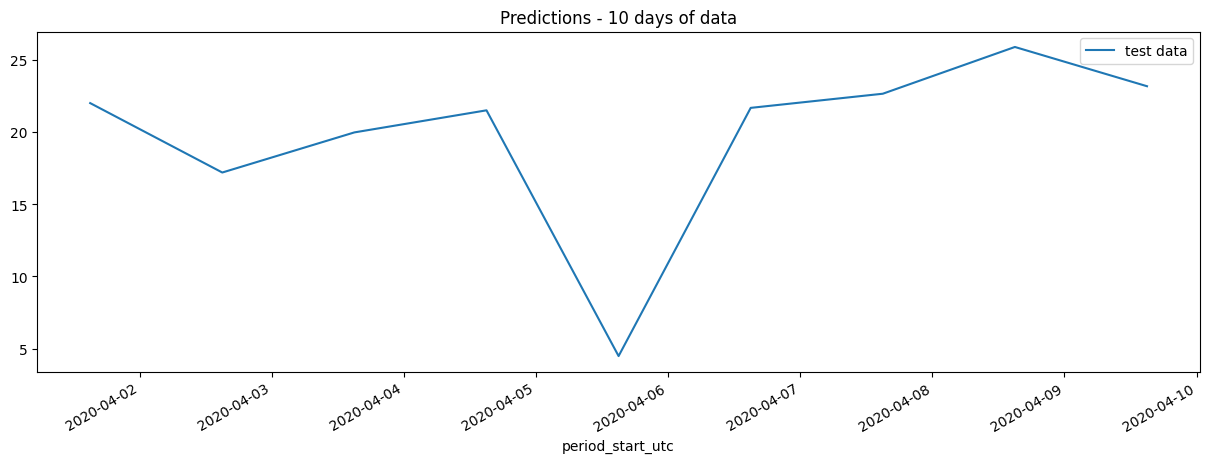

In [33]:
ax = df_years.loc[("2020-04-01" < df_years.index) & (df_years.index < "2020-04-10")]['price'].plot(figsize=(15, 5), title='Predictions - 10 days of data')
plt.legend(['test data'])
plt.show()

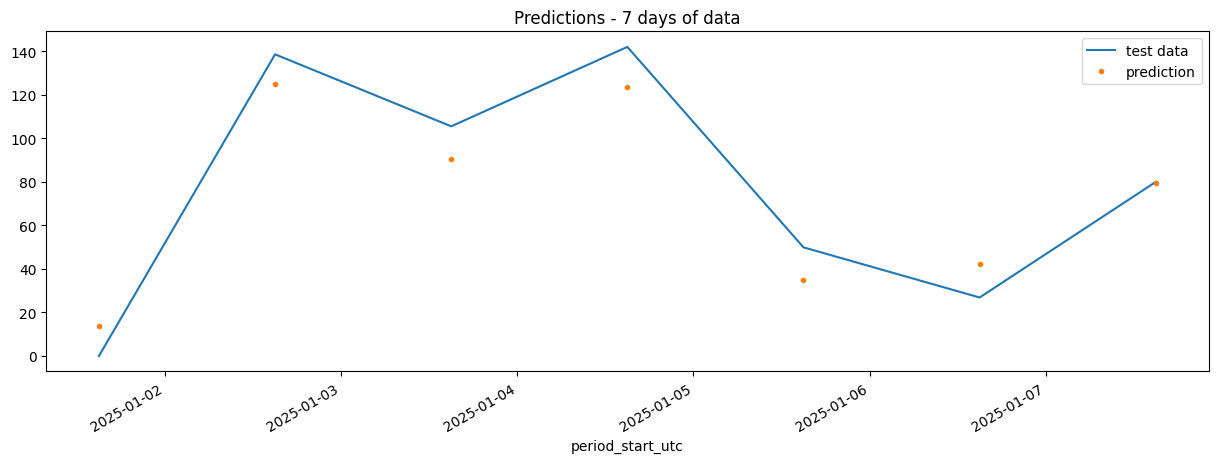

In [34]:
split_date_one_week_in = split_date + add_one_week

ax = df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

# Using Grid/Randomizer Search

In [35]:
# Define the hyperparameter distributions
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'subsample': [0.5, 0.7, 1]
}

In [36]:
xgb_model.paramater_search_XGBoost(train, FEATURES, TARGET, 'grid', param_grid)

Best set of hyperparameters:  {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.5}
Best score:  -37.93278418384594


In [37]:
# Define the hyperparameter distributions
param_dist = {
    'base_score':stats.uniform(0.4, 0.6),
    'max_depth': stats.randint(3, 10),
    'learning_rate': stats.uniform(0.001, 0.1),
    'subsample': stats.uniform(0.5, 0.9),
    'n_estimators':stats.randint(100, 2000),
    'colsample_bytree':stats.uniform(0.5, 0.8)
}

In [38]:
xgb_model.paramater_search_XGBoost(train, FEATURES, TARGET, 'random', param_dist)

c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
80 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Trainings\capstone-data-science\ai-for-energy\.venv\Lib\site-packag

Best set of hyperparameters:  {'base_score': 0.9329841263262167, 'colsample_bytree': 0.9571221338857714, 'learning_rate': 0.053925909327424, 'max_depth': 3, 'n_estimators': 1908, 'subsample': 0.8540823820645214}
Best score:  -38.69102678562777


In [ ]:
# score_train = mean_squared_error(np.log(y_train),np.log(y_predict_train), squared = False)